In [1]:
import os
import io
import zipfile
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

In [3]:
price = pd.read_csv('../data/raw/round_1/prices_round_1_day_-2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean = price_pepper.dropna(subset=price_pepper.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean = price_osmium.dropna(subset=price_osmium.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [4]:
price = pd.read_csv('../data/raw/round_2/prices_round_2_day_-1.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_1 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_1 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_1 = price_pepper_1.dropna(subset=price_pepper_1.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_1 = price_osmium_1.dropna(subset=price_osmium_1.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [5]:
price = pd.read_csv('../data/raw/round_2/prices_round_2_day_0.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_2 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_2 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_2 = price_pepper_2.dropna(subset=price_pepper_2.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_2 = price_osmium_2.dropna(subset=price_osmium_2.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [6]:
price = pd.read_csv('../data/raw/round_2/prices_round_2_day_1.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_3 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_3 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_3 = price_pepper_3.dropna(subset=price_pepper_3.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_3 = price_osmium_3.dropna(subset=price_osmium_3.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

In [7]:
price = pd.read_csv('../data/raw/round_2/prices_round_2_day_2.csv', delimiter=';').drop(columns=['day', 'profit_and_loss'])
price_pepper_4 = price[price['product'] == 'INTARIAN_PEPPER_ROOT']
price_osmium_4 = price[price['product'] == 'ASH_COATED_OSMIUM']
price_pepper_clean_4 = price_pepper_4.dropna(subset=price_pepper_4.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)
price_osmium_clean_4 = price_osmium_4.dropna(subset=price_osmium_4.columns.difference(['timestamp', 'product', 'mid_price']), how='all').reset_index(
    drop=True)

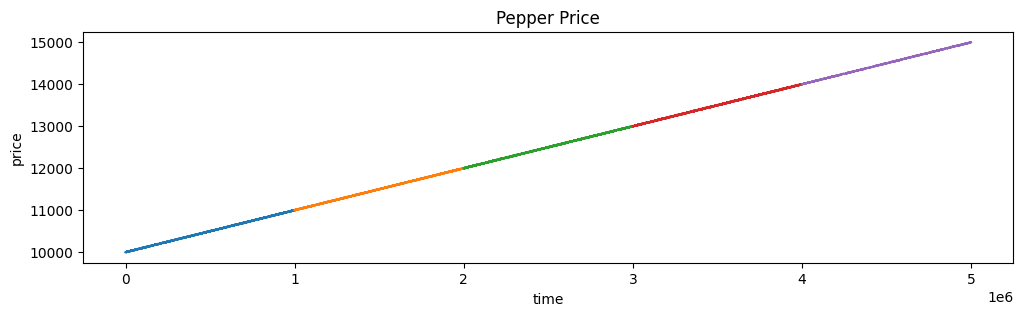

In [8]:
plt.figure(figsize=(12, 3))
plt.plot(price_pepper_clean['timestamp'], price_pepper_clean['mid_price'])
plt.plot(price_pepper_clean_1['timestamp'] + 1000000, price_pepper_clean_1['mid_price'])
plt.plot(price_pepper_clean_2['timestamp'] + 2000000, price_pepper_clean_2['mid_price'])
plt.plot(price_pepper_clean_3['timestamp'] + 3000000, price_pepper_clean_3['mid_price'])
plt.plot(price_pepper_clean_4['timestamp'] + 4000000, price_pepper_clean_4['mid_price'])
plt.title('Pepper Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

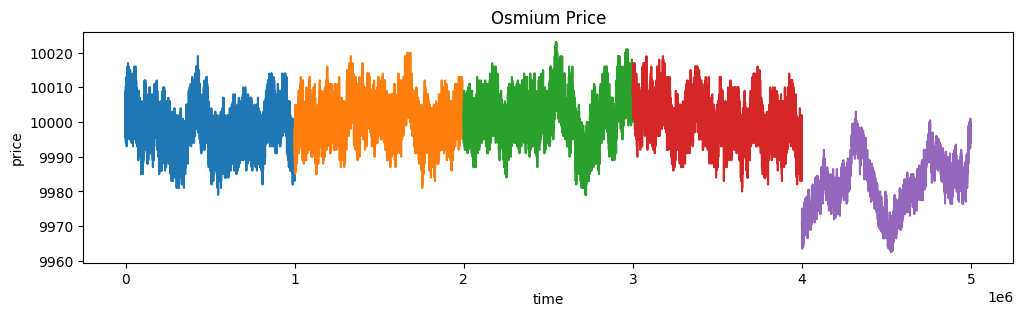

In [9]:
plt.figure(figsize=(12, 3))
plt.plot(price_osmium_clean['timestamp'], price_osmium_clean['mid_price'])
plt.plot(price_osmium_clean_1['timestamp'] + 1000000, price_osmium_clean_1['mid_price'])
plt.plot(price_osmium_clean_2['timestamp'] + 2000000, price_osmium_clean_2['mid_price'])
plt.plot(price_osmium_clean_3['timestamp'] + 3000000, price_osmium_clean_3['mid_price'])
plt.plot(price_osmium_clean_4['timestamp'] + 4000000, price_osmium_clean_4['mid_price'])
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

# INTARIAN_PEPPER_ROOT

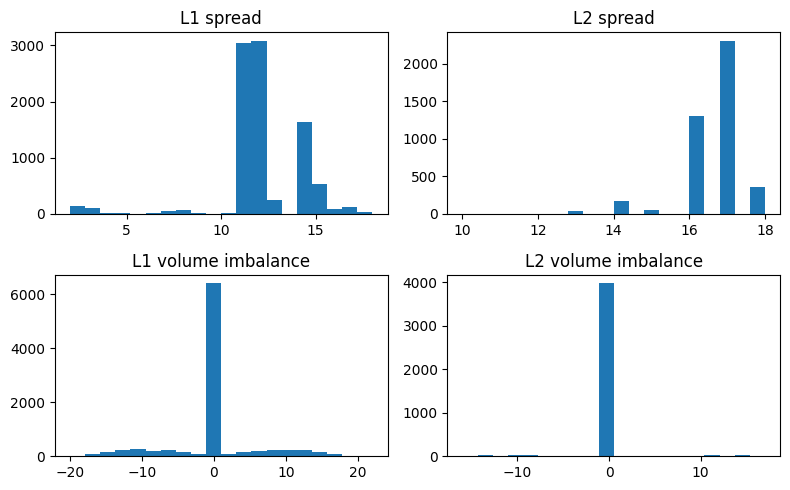

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_pepper_clean['ask_price_1'] - price_pepper_clean['bid_price_1'], bins=20)
ax[0, 1].hist(price_pepper_clean['ask_price_2'] - price_pepper_clean['bid_price_2'], bins=20)
ax[1, 0].hist(price_pepper_clean['ask_volume_1'] - price_pepper_clean['bid_volume_1'], bins=20)
ax[1, 1].hist(price_pepper_clean['ask_volume_2'] - price_pepper_clean['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

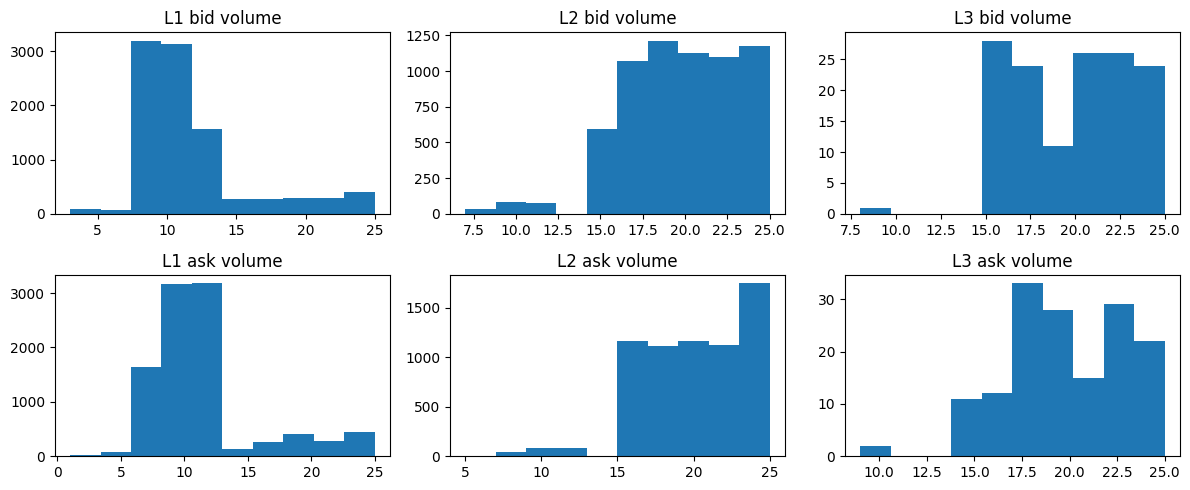

In [11]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_pepper_clean['bid_volume_1'])
ax[0, 1].hist(price_pepper_clean['bid_volume_2'])
ax[0, 2].hist(price_pepper_clean['bid_volume_3'])
ax[1, 0].hist(price_pepper_clean['ask_volume_1'])
ax[1, 1].hist(price_pepper_clean['ask_volume_2'])
ax[1, 2].hist(price_pepper_clean['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [12]:
price_pepper_clean = price_pepper_clean.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))
price_pepper_clean_1 = price_pepper_clean_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))

In [13]:
params = np.polyfit(price_pepper_clean['timestamp']//100, price_pepper_clean['mid_price'], deg=1)

In [14]:
params  # Params to calculate Pepper failr value

array([1.00002881e-01, 9.99997928e+03])

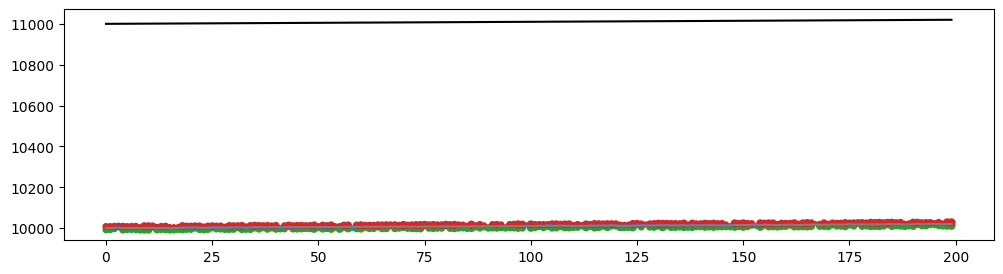

In [15]:
plt.figure(figsize=(12, 3))
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_1'], s=price_pepper_clean.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_2'], s=price_pepper_clean.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['bid_price_3'], s=price_pepper_clean.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_1'], s=price_pepper_clean.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_2'], s=price_pepper_clean.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['ask_price_3'], s=price_pepper_clean.iloc[:200]['ask_volume_3'], c='tab:red')
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['mid_price'])
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['filtered_mid'], c='gray')
plt.plot(price_pepper_clean.iloc[:200]['timestamp']//100, price_pepper_clean.iloc[:200]['timestamp']//100 * 0.1 + 11000, c='k')        
plt.show()

In [16]:
rolling_slope = price_pepper_clean['filtered_mid'].rolling(100).apply(
    lambda x: np.polyfit(np.arange(len(x)), x, 1)[0],
    raw=True
).dropna()

<Axes: >

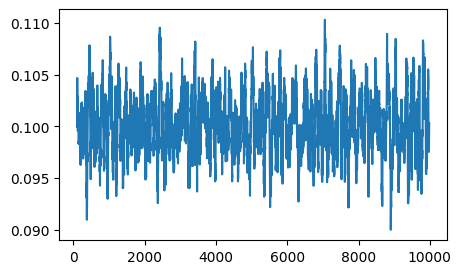

In [17]:
rolling_slope.plot(figsize=(5, 3))

In [18]:
train_logr = np.log(price_pepper_clean['filtered_mid']).diff().dropna()
test_logr = np.log(price_pepper_clean_1['filtered_mid']).diff().dropna()

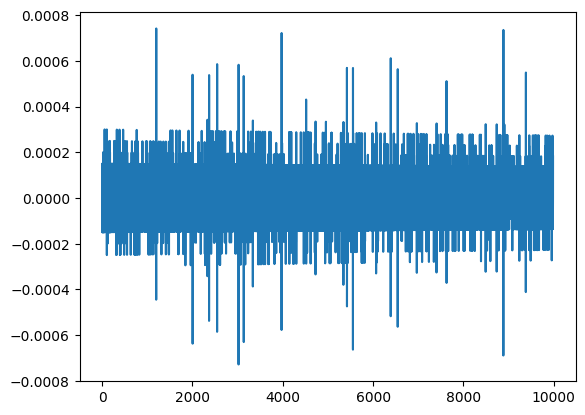

In [19]:
plt.plot(train_logr)

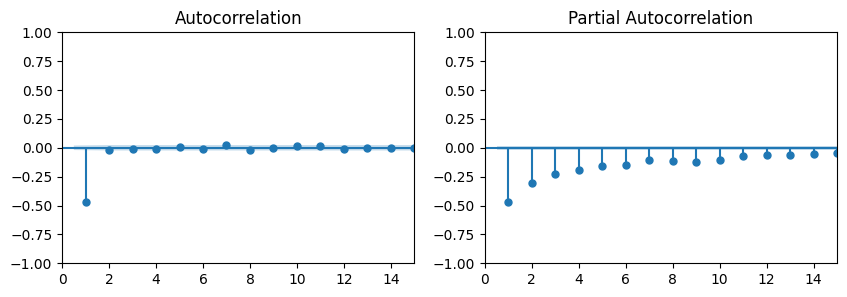

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [21]:
true = test_logr[1:].to_numpy()

In [22]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.0001636530193053898


In [23]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.47, b = 0.0
AR(1) RMSE: 8.64779780550564e-05


# ASH_COATED_OSMIUM

In [24]:
price_osmium_clean.head()

,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price
0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0
1,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0
2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0
3,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0
4,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0


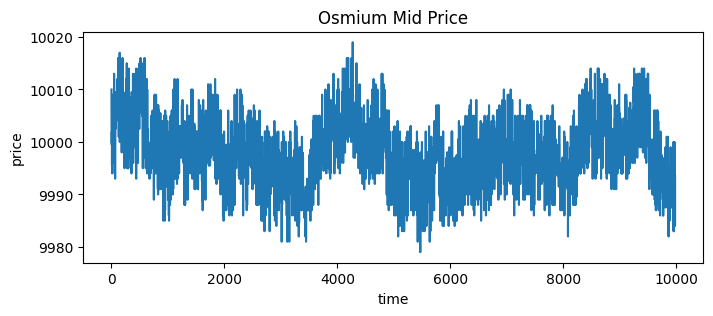

In [25]:
plt.figure(figsize=(8, 3))
plt.plot(price_osmium_clean['mid_price'])
plt.title('Osmium Mid Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

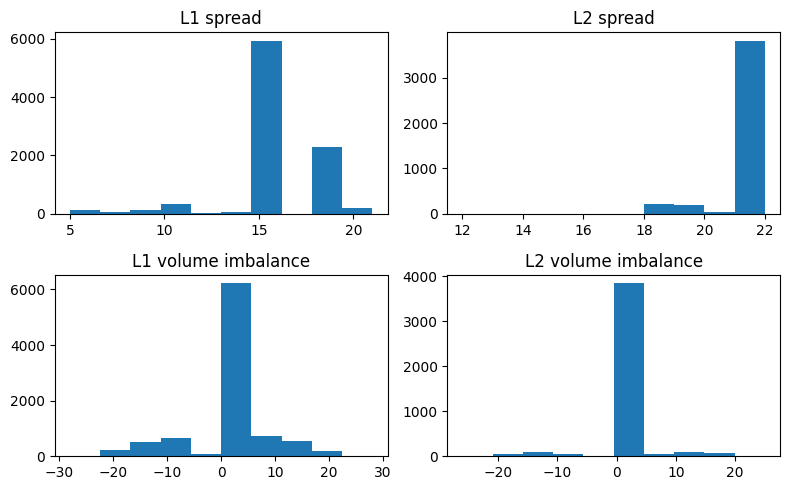

In [26]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_osmium_clean['ask_price_1'] - price_osmium_clean['bid_price_1'])
ax[0, 1].hist(price_osmium_clean['ask_price_2'] - price_osmium_clean['bid_price_2'])
ax[1, 0].hist(price_osmium_clean['ask_volume_1'] - price_osmium_clean['bid_volume_1'])
ax[1, 1].hist(price_osmium_clean['ask_volume_2'] - price_osmium_clean['bid_volume_2'])
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

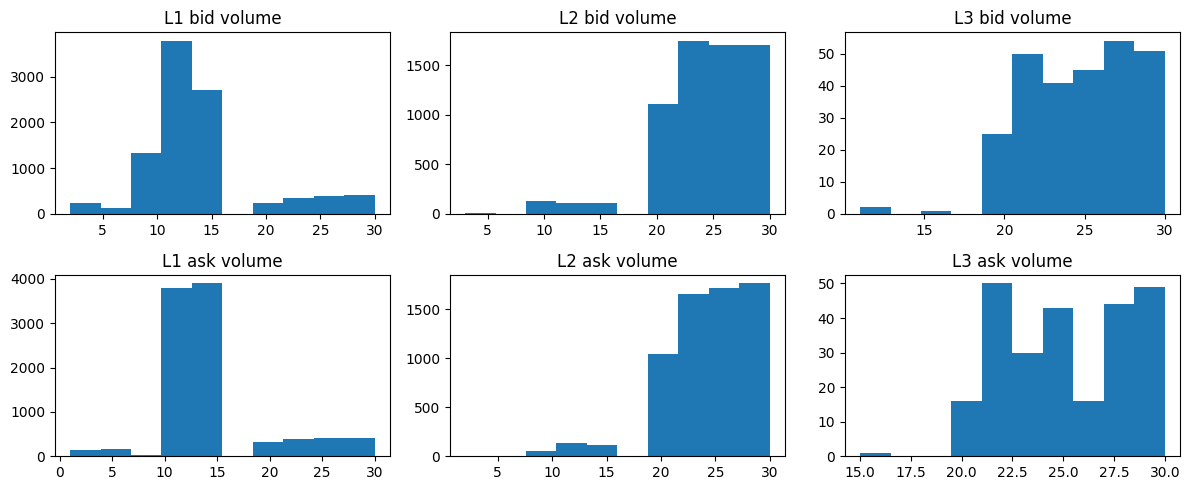

In [27]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_osmium_clean['bid_volume_1'])
ax[0, 1].hist(price_osmium_clean['bid_volume_2'])
ax[0, 2].hist(price_osmium_clean['bid_volume_3'])
ax[1, 0].hist(price_osmium_clean['ask_volume_1'])
ax[1, 1].hist(price_osmium_clean['ask_volume_2'])
ax[1, 2].hist(price_osmium_clean['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [28]:
# price_osmium_clean = price_osmium_clean.assign(filtered_mid=(price_osmium_clean['bid_price_2'] + price_osmium_clean['ask_price_2']) / 2)
# price_osmium_clean['filtered_mid'] = price_osmium_clean['filtered_mid'].ffill()

In [29]:
price_osmium_clean = price_osmium_clean.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))
price_osmium_clean_1 = price_osmium_clean_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))
price_osmium_clean_2 = price_osmium_clean_2.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=20))

In [30]:
price_osmium_clean['filtered_mid']

0           NaN
1       10001.5
2        9999.5
3        9999.5
4       10001.0
         ...   
9977     9992.5
9978     9992.5
9979     9992.5
9980     9992.5
9981     9993.5
Name: filtered_mid, Length: 9982, dtype: float64

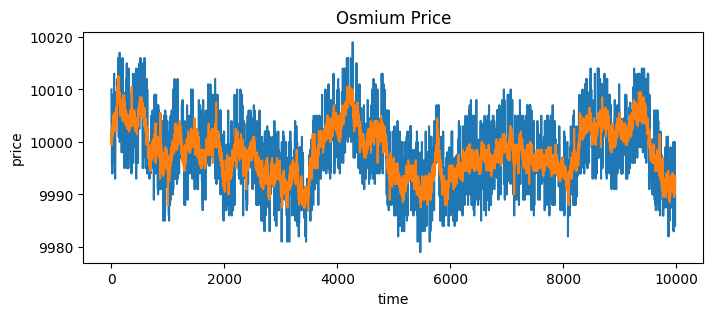

In [31]:
plt.figure(figsize=(8, 3))
plt.plot(price_osmium_clean['mid_price'])
plt.plot(price_osmium_clean['filtered_mid'])
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

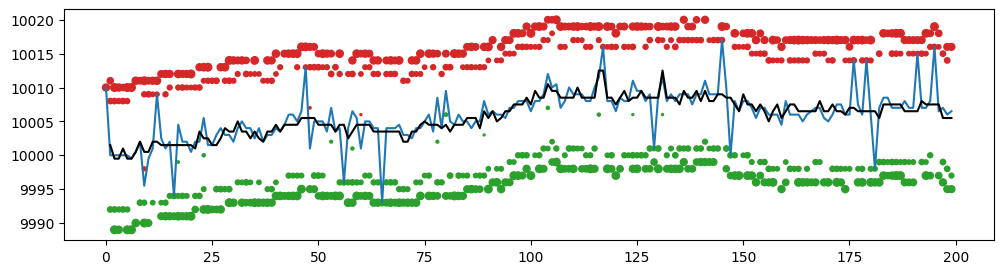

In [32]:
plt.figure(figsize=(12, 3))
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_1'], s=price_osmium_clean.iloc[:200]['bid_volume_1'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_2'], s=price_osmium_clean.iloc[:200]['bid_volume_2'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['bid_price_3'], s=price_osmium_clean.iloc[:200]['bid_volume_3'], c='tab:green')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_1'], s=price_osmium_clean.iloc[:200]['ask_volume_1'], c='tab:red')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_2'], s=price_osmium_clean.iloc[:200]['ask_volume_2'], c='tab:red')
plt.scatter(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['ask_price_3'], s=price_osmium_clean.iloc[:200]['ask_volume_3'], c='tab:red')
plt.plot(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['mid_price'])
plt.plot(price_osmium_clean.iloc[:200]['timestamp']//100, price_osmium_clean.iloc[:200]['filtered_mid'], c='k')
plt.show()

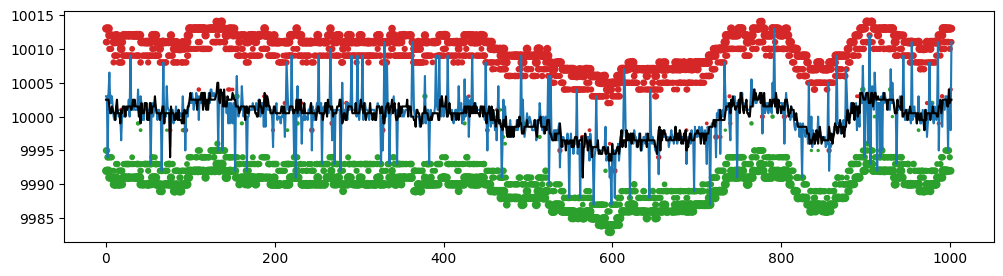

In [33]:
l = 1000
plt.figure(figsize=(12, 3))
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['bid_price_1'], s=price_osmium_clean_2.iloc[:l]['bid_volume_1'], c='tab:green')
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['bid_price_2'], s=price_osmium_clean_2.iloc[:l]['bid_volume_2'], c='tab:green')
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['bid_price_3'], s=price_osmium_clean_2.iloc[:l]['bid_volume_3'], c='tab:green')
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['ask_price_1'], s=price_osmium_clean_2.iloc[:l]['ask_volume_1'], c='tab:red')
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['ask_price_2'], s=price_osmium_clean_2.iloc[:l]['ask_volume_2'], c='tab:red')
plt.scatter(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['ask_price_3'], s=price_osmium_clean_2.iloc[:l]['ask_volume_3'], c='tab:red')
plt.plot(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['mid_price'])
plt.plot(price_osmium_clean_2.iloc[:l]['timestamp']//100, price_osmium_clean_2.iloc[:l]['filtered_mid'], c='k')
plt.show()

In [34]:
print(price_osmium_clean['filtered_mid'].mean(), price_osmium_clean_1['filtered_mid'].mean(), price_osmium_clean_2['filtered_mid'].mean())
print(pd.concat([price_osmium_clean['filtered_mid'], price_osmium_clean_1['filtered_mid'], price_osmium_clean_2['filtered_mid']]).reset_index(drop=True).mean())
print(price_osmium_clean['filtered_mid'].std(), price_osmium_clean_1['filtered_mid'].std(), price_osmium_clean_2['filtered_mid'].std())
print(pd.concat([price_osmium_clean['filtered_mid'], price_osmium_clean_1['filtered_mid'], price_osmium_clean_2['filtered_mid']]).reset_index(drop=True).std())

9998.155996393147 10000.84481722584 10001.63892227564
10000.21347245409
4.615595172801162 3.7027917164669923 5.117093450144365
4.7559488551705345


In [35]:
osmium_mean = 10000
osmium_std = 4.75

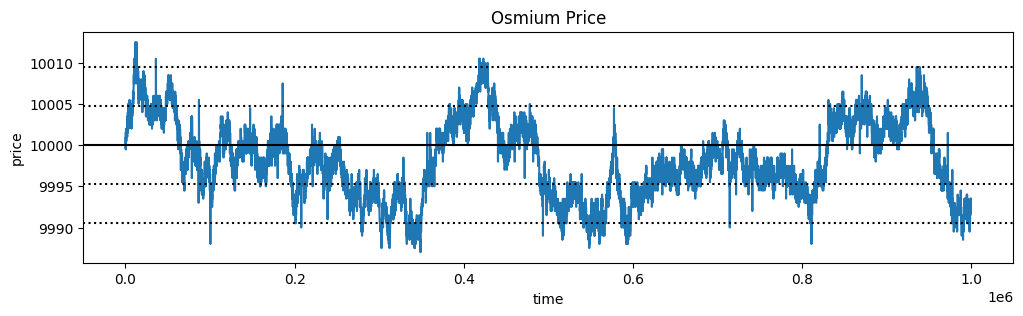

In [36]:
plt.figure(figsize=(12, 3))
plt.plot(price_osmium_clean['timestamp'], price_osmium_clean['filtered_mid'])
plt.axhline(osmium_mean, c='k')
plt.axhline(osmium_mean + 1 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean - 1 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean + 2 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean - 2 * osmium_std, c='k', linestyle='dotted')
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

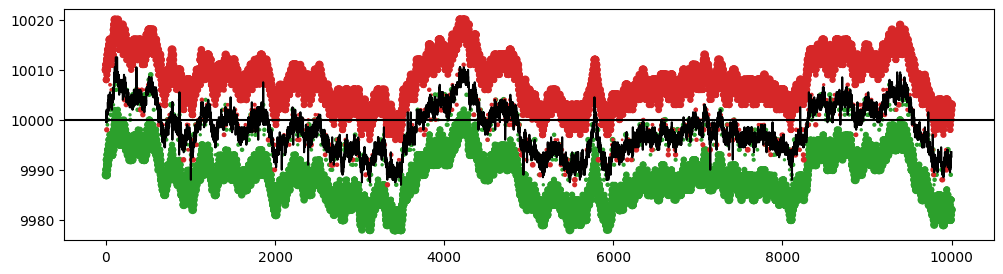

In [37]:
plt.figure(figsize=(12, 3))
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['bid_price_1'], s=price_osmium_clean['bid_volume_1'], c='tab:green')
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['bid_price_2'], s=price_osmium_clean['bid_volume_2'], c='tab:green')
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['bid_price_3'], s=price_osmium_clean['bid_volume_3'], c='tab:green')
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['ask_price_1'], s=price_osmium_clean['ask_volume_1'], c='tab:red')
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['ask_price_2'], s=price_osmium_clean['ask_volume_2'], c='tab:red')
plt.scatter(price_osmium_clean['timestamp']//100, price_osmium_clean['ask_price_3'], s=price_osmium_clean['ask_volume_3'], c='tab:red')
plt.plot(price_osmium_clean['timestamp']//100, price_osmium_clean['filtered_mid'], c='k')
plt.axhline(10000, c='k')
plt.show()

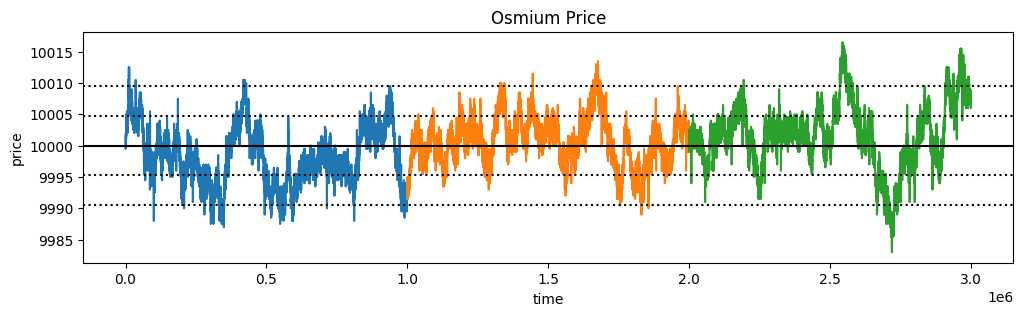

In [38]:
plt.figure(figsize=(12, 3))
plt.plot(price_osmium_clean['timestamp'], price_osmium_clean['filtered_mid'])
plt.plot(price_osmium_clean_1['timestamp'] + 1000000, price_osmium_clean_1['filtered_mid'])
plt.plot(price_osmium_clean_2['timestamp'] + 2000000, price_osmium_clean_2['filtered_mid'])
plt.axhline(osmium_mean, c='k')
plt.axhline(osmium_mean + 1 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean - 1 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean + 2 * osmium_std, c='k', linestyle='dotted')
plt.axhline(osmium_mean - 2 * osmium_std, c='k', linestyle='dotted')
plt.title('Osmium Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

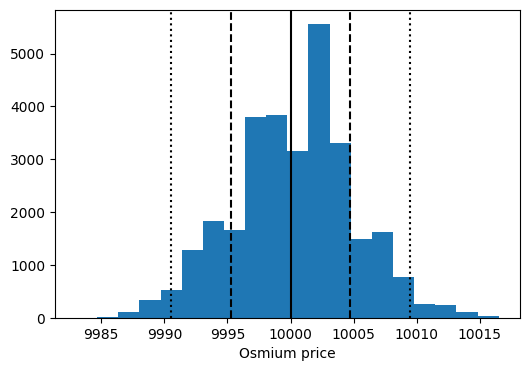

In [39]:
plt.figure(figsize=(6, 4))
plt.hist(pd.concat([price_osmium_clean['filtered_mid'], price_osmium_clean_1['filtered_mid'],
                    price_osmium_clean_2['filtered_mid']]).reset_index(drop=True).dropna(), bins=20)
plt.axvline(osmium_mean, c='k')
plt.axvline(osmium_mean + osmium_std, c='k', linestyle='dashed')
plt.axvline(osmium_mean - osmium_std, c='k', linestyle='dashed')
plt.axvline(osmium_mean + 2 * osmium_std, c='k', linestyle='dotted')
plt.axvline(osmium_mean - 2 * osmium_std, c='k', linestyle='dotted')
plt.xlabel('Osmium price')
plt.show()

In [40]:
imbalance = (price_osmium_clean.fillna(0)['bid_volume_2'] + price_osmium_clean.fillna(0)['bid_volume_3']) - \
    (price_osmium_clean.fillna(0)['ask_volume_2'] + price_osmium_clean.fillna(0)['ask_volume_3'])
price_osmium_clean = price_osmium_clean.assign(imbalance=imbalance)

In [41]:
y = price_osmium_clean[(price_osmium_clean['imbalance'] >= 20) | (price_osmium_clean['imbalance'] <= -20)]['filtered_mid'].diff(periods=1).dropna()
x = price_osmium_clean[(price_osmium_clean['imbalance'] >= 20) | (price_osmium_clean['imbalance'] <= -20)]['imbalance'].iloc[-len(y):]
m, c = np.polyfit(x, y, 1)
print(m)

-0.022968441269811193


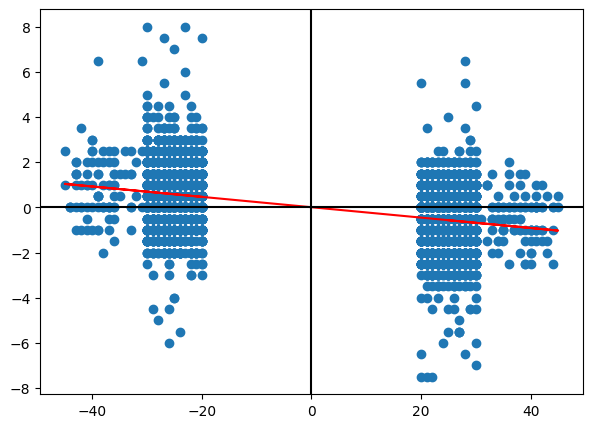

In [42]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y)
plt.plot(x, m * x + c, c='r')
plt.axhline(0, c='k')
plt.axvline(0, c='k')
plt.show()

In [43]:
train_logr = np.log(price_osmium_clean['filtered_mid']).diff().dropna()
test_logr = np.log(price_osmium_clean_1['filtered_mid']).diff().dropna()

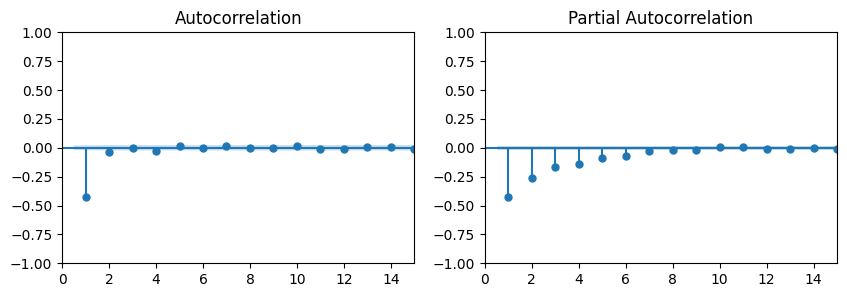

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [45]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

        lb_stat  lb_pvalue
10  1823.505882        0.0
Reject null hypothesis: data is not white noise.


In [46]:
true = test_logr[1:].to_numpy()

In [47]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.00018178239030744166


In [48]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.42, b = -0.0
AR(1) RMSE: 9.847518533151672e-05


# Max willingness to pay for Extra 20% quotes

In [49]:
# Backtest results
pepper_backtest_pnls = [79551.50, 80241.00, 80573.00]
osmium_backtest_pnls = [20541.00, 21306.00, 20458.00]
pepper_no_taking_backtest_pnls = [60228.50, 54315.00, 51538.50]
osmium_no_taking_backtest_pnls = [17997.00, 18118.00, 17394.00]

pepper_backtest_pnl = np.mean(pepper_backtest_pnls)
osmium_backtest_pnl = np.mean(osmium_backtest_pnls)
pepper_no_taking_backtest_pnl = np.mean(pepper_no_taking_backtest_pnls)
osmium_no_taking_backtest_pnl = np.mean(osmium_no_taking_backtest_pnls)

total_backtest_pnl = pepper_backtest_pnl + osmium_backtest_pnl
total_no_taking_backtest_pnl = pepper_no_taking_backtest_pnl + osmium_no_taking_backtest_pnl

pepper_taking_ratio = (pepper_backtest_pnl - pepper_no_taking_backtest_pnl) / pepper_backtest_pnl
osmium_taking_ratio = (osmium_backtest_pnl - osmium_no_taking_backtest_pnl) / osmium_backtest_pnl
total_taking_ratio = (total_backtest_pnl - total_no_taking_backtest_pnl) / total_backtest_pnl

print(f"Average ratio of Pepper PnL due to market-taking: {pepper_taking_ratio}")
print(f"Average ratio of Osmium PnL due to market-taking: {osmium_taking_ratio}")
print(f"Average ratio of Total PnL due to market-taking: {total_taking_ratio}")

Average ratio of Pepper PnL due to market-taking: 0.309043935173725
Average ratio of Osmium PnL due to market-taking: 0.1411764705882353
Average ratio of Total PnL due to market-taking: 0.2744882636398327


In [51]:
zip_files

['291877.zip', '316660.zip', '317039.zip', '317128.zip', '317329.zip', 'final']

In [52]:
path = '../data/logs/round_2'
zip_files = os.listdir(path)[:-1]

pepper_pnls, osmium_pnls = [], []
for f in zip_files:
    zip_file_path = os.path.join(path, f)
    with zipfile.ZipFile(zip_file_path, 'r') as archive:
        files = archive.namelist()
        json_filename = [f for f in files if f[-4:]=='json']
        log_filename = [f for f in files if f[-3:]=='log']
        assert len(json_filename) == 1, "More than one json file in the log archive"
        assert len(log_filename) == 1, "More than one log file in the log archive"
        json_filename = json_filename[0]
        log_filename = log_filename[0]
        
        with archive.open(json_filename) as json_file:
            data_json = json.load(json_file)
        with archive.open(log_filename) as log_file:
            data_log = json.load(log_file)
    
    activities = pd.read_csv(io.StringIO(data_log['activitiesLog']), sep=';')
    trades = pd.DataFrame(data_log['tradeHistory'])
    
    price_pepper = activities[activities['product'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
    price_osmium = activities[activities['product'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')
    trades_pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].reset_index(drop=True).set_index('timestamp')
    trades_osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].reset_index(drop=True).set_index('timestamp')

    pepper_pnls.append(price_pepper['profit_and_loss'].iloc[-1])
    osmium_pnls.append(price_osmium['profit_and_loss'].iloc[-1])

In [53]:
pepper_pnl = np.mean(pepper_pnls)
osmium_pnl = np.mean(osmium_pnls)

pepper_taking_pnl = np.mean(pepper_pnls) * pepper_taking_ratio
osmium_taking_pnl = np.mean(osmium_pnls) * osmium_taking_ratio

print(f"Average Pepper PnL: {pepper_pnl}")
print(f"Average Osmium PnL: {osmium_pnl}")
print()
print(f"Average Pepper taking PnL: {pepper_taking_pnl}")
print(f"Average Osmium taking PnL: {osmium_taking_pnl}")

Average Pepper PnL: 7399.05
Average Osmium PnL: 1856.908203125

Average Pepper taking PnL: 2286.63152854715
Average Osmium taking PnL: 262.1517463235294


In [54]:
gain = (pepper_taking_pnl + osmium_taking_pnl) * 0.25 * 10  # The testing period is 1/10 of a trading day
print(f"Expected PnL gain due to 25% more quotes in the order book (MWTP): {gain}")

Expected PnL gain due to 25% more quotes in the order book (MWTP): 6371.958187176699


In [55]:
# Assuming similar taking ratios:
median_algo_pnl = 88041  # Over one trading day
median_taking_pnl = median_algo_pnl * total_taking_ratio
median_gain = median_taking_pnl * 0.25
print(f"Expected median PnL gain among profitable participants due to 25% more quotes in the order book (median MWTP): {median_gain}")

Expected median PnL gain among profitable participants due to 25% more quotes in the order book (median MWTP): 6041.555304778628


In [56]:
# Assumption: A smart competitor will likely bid roughly 20% to 30% of their MWTP
print(f"Bid amount: {int(6041 * 0.35) + np.random.randint(10, 20)}")

Bid amount: 2126
